<a href="https://colab.research.google.com/github/Uday-SR/Computer-Vision2/blob/main/Impact_of_Image_Degradation_on_ANN_Based_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
input_dir = '/content/drive/MyDrive/Datasets/flowers'
os.listdir(input_dir)

['tulip', 'sunflower', 'rose', 'dandelion', 'daisy']

In [4]:
output_dirs = {
    "V1": "/content/drive/MyDrive/Datasets/flowers_V1",
    "V2": "/content/drive/MyDrive/Datasets/flowers_V2",
    "V3": "/content/drive/MyDrive/Datasets/flowers_V3",
}

In [5]:
for folder in output_dirs.values():
  os.makedirs(folder, exist_ok=True)

In [6]:
for class_name in os.listdir(input_dir):
  class_path = os.path.join(input_dir, class_name)

  if not os.path.isdir(class_path):
    continue

  for dataset in output_dirs.values():
    os.makedirs(os.path.join(dataset, class_name), exist_ok=True)

  for img_name in os.listdir(class_path):
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)

    if img is None:
      continue

    # Resize
    img = cv2.resize(img, (128, 128))

    # Original

    cv2.imwrite(os.path.join(output_dirs['V1'], class_name, img_name), img)

    # Gaussian Noise + blur

    noise = np.random.normal(0, 25, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    blur = cv2.GaussianBlur(noisy, (5, 5), 1.5)

    cv2.imwrite(os.path.join(output_dirs['V2'], class_name, img_name), blur)

    #Dark Images + Bright Images

    dark = cv2.convertScaleAbs(img, alpha=0.5, beta=0)

    bright = cv2.convertScaleAbs(img, alpha=1.0, beta=0)

    cv2.imwrite(os.path.join(output_dirs['V3'], class_name, img_name), bright)

print("done")

done


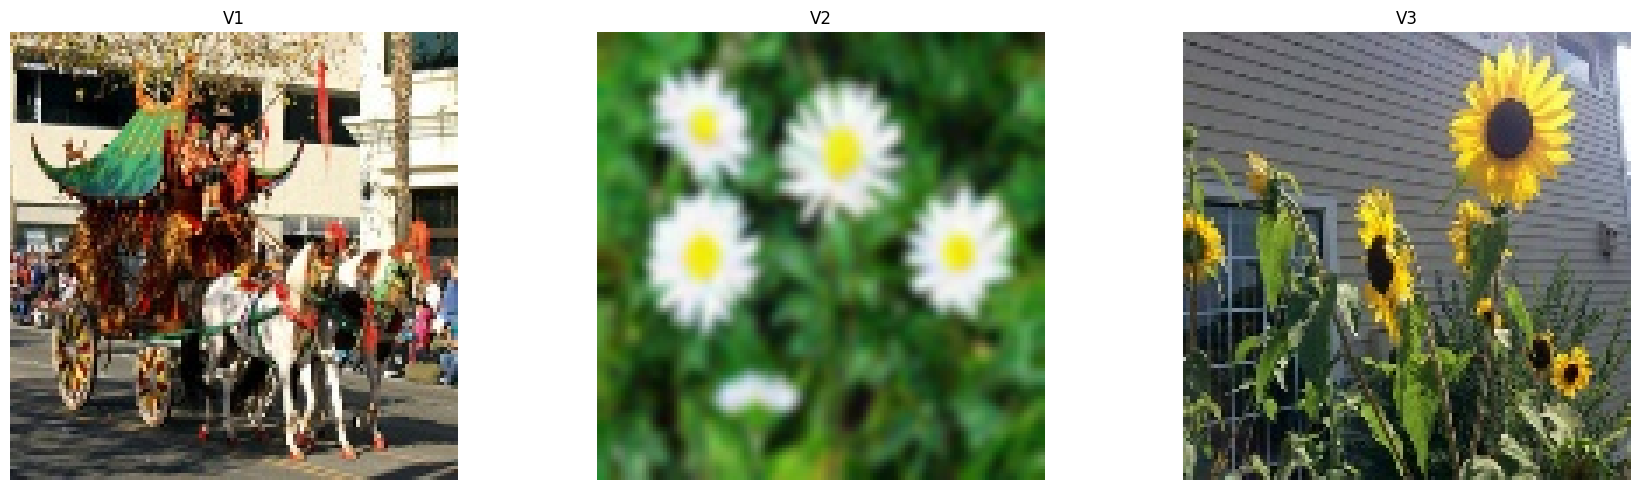

In [12]:
# Processed datasets image

plt.figure(figsize=(18,5))

for i, (dataset_name, dataset_path) in enumerate(output_dirs.items()):

    # Get all image paths
    image_paths = []

    for class_name in os.listdir(dataset_path):

        class_path = os.path.join(dataset_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, img_name))

    # Choose one random image
    random_image = random.choice(image_paths)

    # Read image
    img = cv2.imread(random_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display
    plt.subplot(1, len(output_dirs), i+1)
    plt.imshow(img)
    plt.title(dataset_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
## Feature preparation

# Color Histogram Features

def extract_histogram_features(input_dir, bins=16):

  features = []
  labels = []
  img_paths = []

  for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)

    if not os.path.isdir(class_path):
      continue

    for dataset in output_dirs.values():
      os.makedirs(os.path.join(dataset, class_name), exist_ok=True)

    for img_name in os.listdir(class_path):
      img_path = os.path.join(class_path, img_name)

      img = cv2.imread(img_path)

      if img is None:
        continue

      # calculate histogram

      hist_r = cv2.calcHist([img], [0], None, [bins], [0, 256])
      hist_g = cv2.calcHist([img], [1], None, [bins], [0, 256])
      hist_b = cv2.calcHist([img], [2], None, [bins], [0, 256])

      # Normalize and flatten

      hist_r = cv2.normalize(hist_r, hist_r).flatten()
      hist_g = cv2.normalize(hist_g, hist_g).flatten()
      hist_b = cv2.normalize(hist_b, hist_b).flatten()

      #concatenate

      feature = np.concatenate((hist_r, hist_g, hist_b))

      features.append(feature)
      labels.append(class_name)
      img_paths.append(img_path)

  return np.array(features), labels, img_paths

In [14]:
# Apply Feature extraction

all_features = {}

for name, path in output_dirs.items():
    X, y, img_paths = extract_histogram_features(path)

    all_features[name] = {
        "X": X,
        "y": y,
        "paths": img_paths
    }

    print(f"{name}: {X.shape}")

V1: (4317, 48)
V2: (4317, 48)
V3: (4317, 48)


In [15]:
# Normalize the features

scaler = StandardScaler()

for name in all_features:
    X = all_features[name]["X"]

    X = scaler.fit_transform(X)

    all_features[name]["X"] = X

In [17]:
# Encode labels

encoder = LabelEncoder()

# Fit only once using the original dataset labels
encoder.fit(all_features["V1"]["y"])

for name in all_features:
    y = encoder.transform(all_features[name]["y"])
    all_features[name]["y"] = y

In [18]:
# train test split

datasets = {}

for name in all_features:

    X = all_features[name]["X"]
    y = all_features[name]["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    datasets[name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

In [19]:
# ANN

results = []
conf_matrices = {}
histories = {}

for name in datasets:

    model = Sequential([
        Dense(128, activation="relu", input_shape=(48,)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        datasets[name]["X_train"],
        datasets[name]["y_train"],
        epochs=30,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    pred = model.predict(datasets[name]["X_test"], verbose=0)
    pred = pred.argmax(axis=1)

    y_test = datasets[name]["y_test"]

    # Store confusion matrix

    conf_matrices[name] = confusion_matrix(y_test, pred)

    # Store evaluation metrics

    results.append({
        "Dataset": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1": f1_score(y_test, pred, average="weighted")
    })

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
results_df = pd.DataFrame(results)
print(results_df)

  Dataset  Accuracy  Precision    Recall        F1
0      V1  0.517361   0.523396  0.517361  0.515705
1      V2  0.505787   0.510048  0.505787  0.505365
2      V3  0.528935   0.532020  0.528935  0.525573


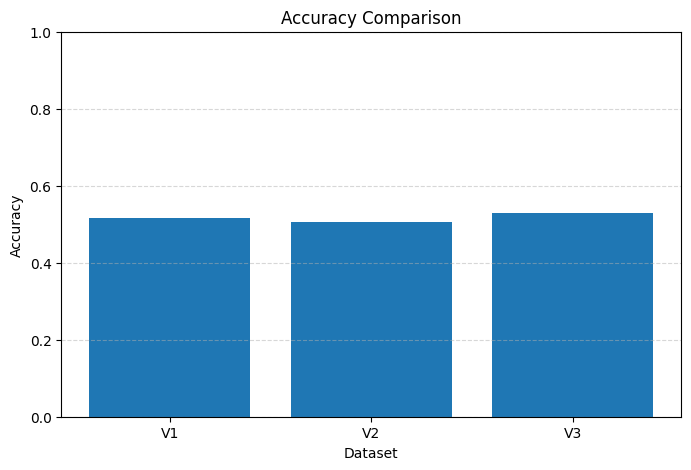

In [21]:
# Accuracy Comparison Bar Chart

plt.figure(figsize=(8,5))

plt.bar(results_df["Dataset"], results_df["Accuracy"])

plt.title("Accuracy Comparison")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")

plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

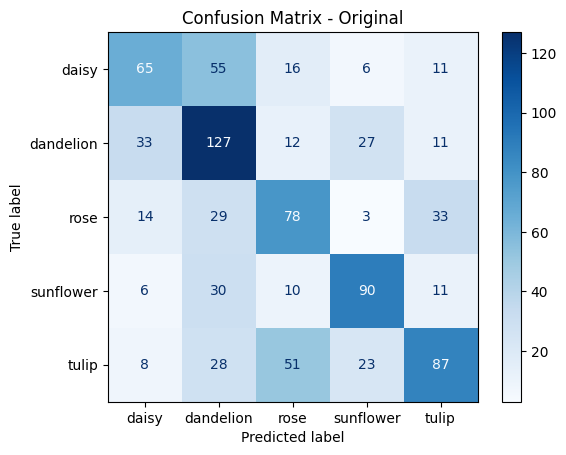

In [23]:
# Original Confusion Matrix

ConfusionMatrixDisplay(
    confusion_matrix=conf_matrices["V1"],
    display_labels=encoder.classes_
).plot(cmap="Blues")

plt.title("Confusion Matrix - Original")
plt.show()

Worst Dataset: V2


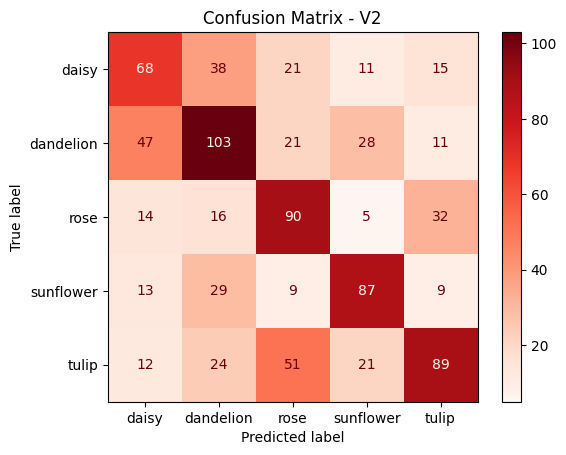

In [24]:
# Worst Performing Dataset

worst_dataset = results_df.loc[
    results_df["Accuracy"].idxmin(),
    "Dataset"
]

print("Worst Dataset:", worst_dataset)

ConfusionMatrixDisplay(
    confusion_matrix=conf_matrices[worst_dataset],
    display_labels=encoder.classes_
).plot(cmap="Reds")

plt.title(f"Confusion Matrix - {worst_dataset}")

plt.show()

In [26]:
# Accuracy Drop Analysis

original_acc = results_df.loc[
    results_df["Dataset"] == "V1",
    "Accuracy"
].iloc[0]

results_df["Accuracy Drop"] = (
    original_acc - results_df["Accuracy"]
)

results_df

,Dataset,Accuracy,Precision,Recall,F1,Accuracy Drop
0,V1,0.517361,0.523396,0.517361,0.515705,0.000000
1,V2,0.505787,0.510048,0.505787,0.505365,0.011574
2,V3,0.528935,0.532020,0.528935,0.525573,-0.011574


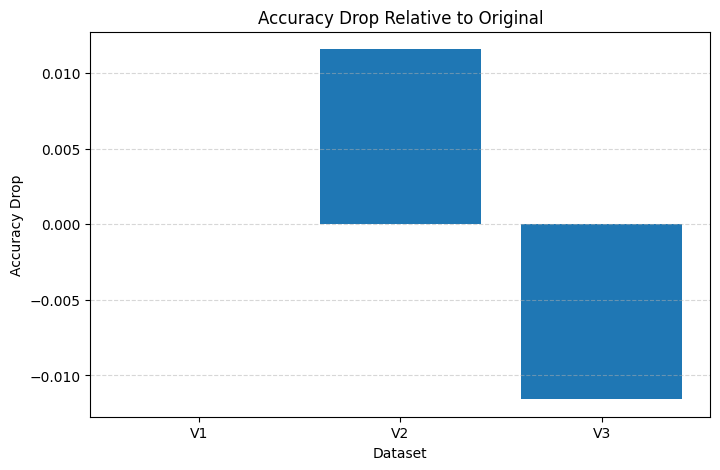

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Dataset"],
    results_df["Accuracy Drop"]
)

plt.title("Accuracy Drop Relative to Original")
plt.xlabel("Dataset")
plt.ylabel("Accuracy Drop")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()